In [ ]:
import pandas as pd
import numpy as np
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [ ]:
df = pd.read_csv("/content/Tasks WDA - ANALYSIS.csv")

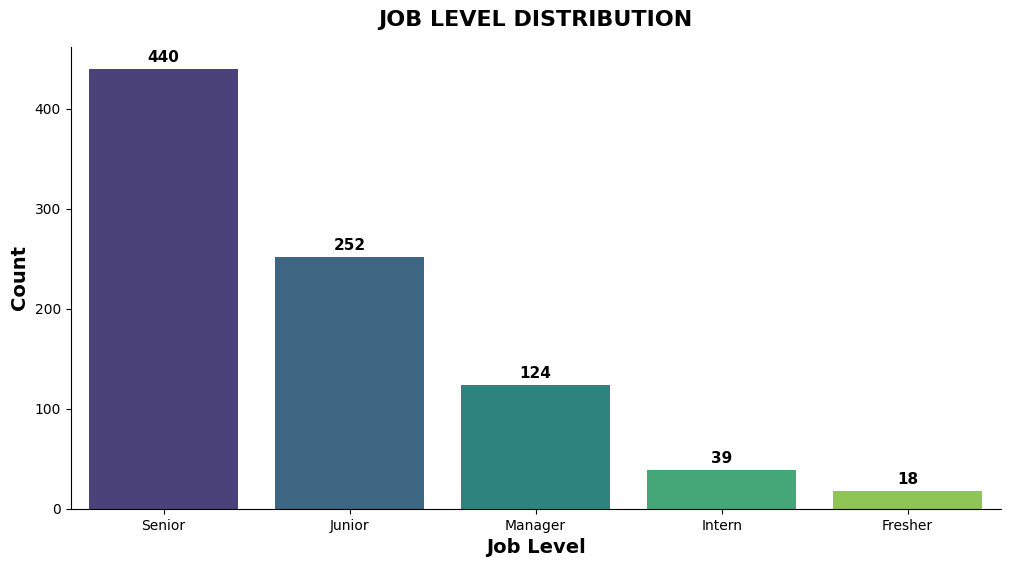

In [ ]:
#Figure 3.9. Number of Jobs by Job Level
plt.figure(figsize=(12, 6))

sns.countplot(x='job_level', data=df,
              hue='job_level', palette='viridis', legend=False)

plt.title('Job Level Distribution'.upper(), fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Job Level', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=14, fontweight='bold')

for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{int(height)}', (p.get_x() + p.get_width()/2., height),
                           ha='center', va='baseline', fontsize=11, fontweight='bold',
                           xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.show()

In [ ]:
df.shape

(873, 45)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 873 entries, 0 to 872
Data columns (total 45 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               873 non-null    object 
 1   experience_min       873 non-null    float64
 2   experience_max       873 non-null    float64
 3   salary_min           873 non-null    float64
 4   salary_max           873 non-null    float64
 5   salary_avg           873 non-null    float64
 6   experience_avg       873 non-null    float64
 7   job_level            873 non-null    object 
 8   year                 873 non-null    int64  
 9   month                873 non-null    int64  
 10  quarter              873 non-null    int64  
 11  day                  873 non-null    int64  
 12  location_list        873 non-null    object 
 13  region               873 non-null    object 
 14  accounting           873 non-null    int64  
 15  reporting            873 non-null    int

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True) * 100)


job_id
job_id
35C64987    0.343643
35C6BAAB    0.343643
35C63BBD    0.343643
35C6801D    0.343643
35C63018    0.343643
              ...   
35C6AD60    0.114548
35C6A501    0.114548
35C6387F    0.114548
35C6AFFB    0.114548
35C63052    0.114548
Name: proportion, Length: 843, dtype: float64

job_level
job_level
Senior     50.400916
Junior     28.865979
Manager    14.203895
Intern      4.467354
Fresher     2.061856
Name: proportion, dtype: float64

location_list
location_list
Ho Chi Minh    41.466208
Ha Noi         37.457045
Binh Duong      4.925544
Long An         3.321879
Dong Nai        2.290951
Hung Yen        1.603666
Da Nang         0.916380
Can Tho         0.801833
Hai Phong       0.687285
Dong Thap       0.572738
Ba Ria-VT       0.572738
Nghe An         0.458190
Quang Ninh      0.458190
Kien Giang      0.458190
Bac Ninh        0.458190
Tien Giang      0.458190
Binh Thuan      0.343643
An Giang        0.343643
Ha Nam          0.343643
Lam Dong        0.229095
Tay Ninh        0.22

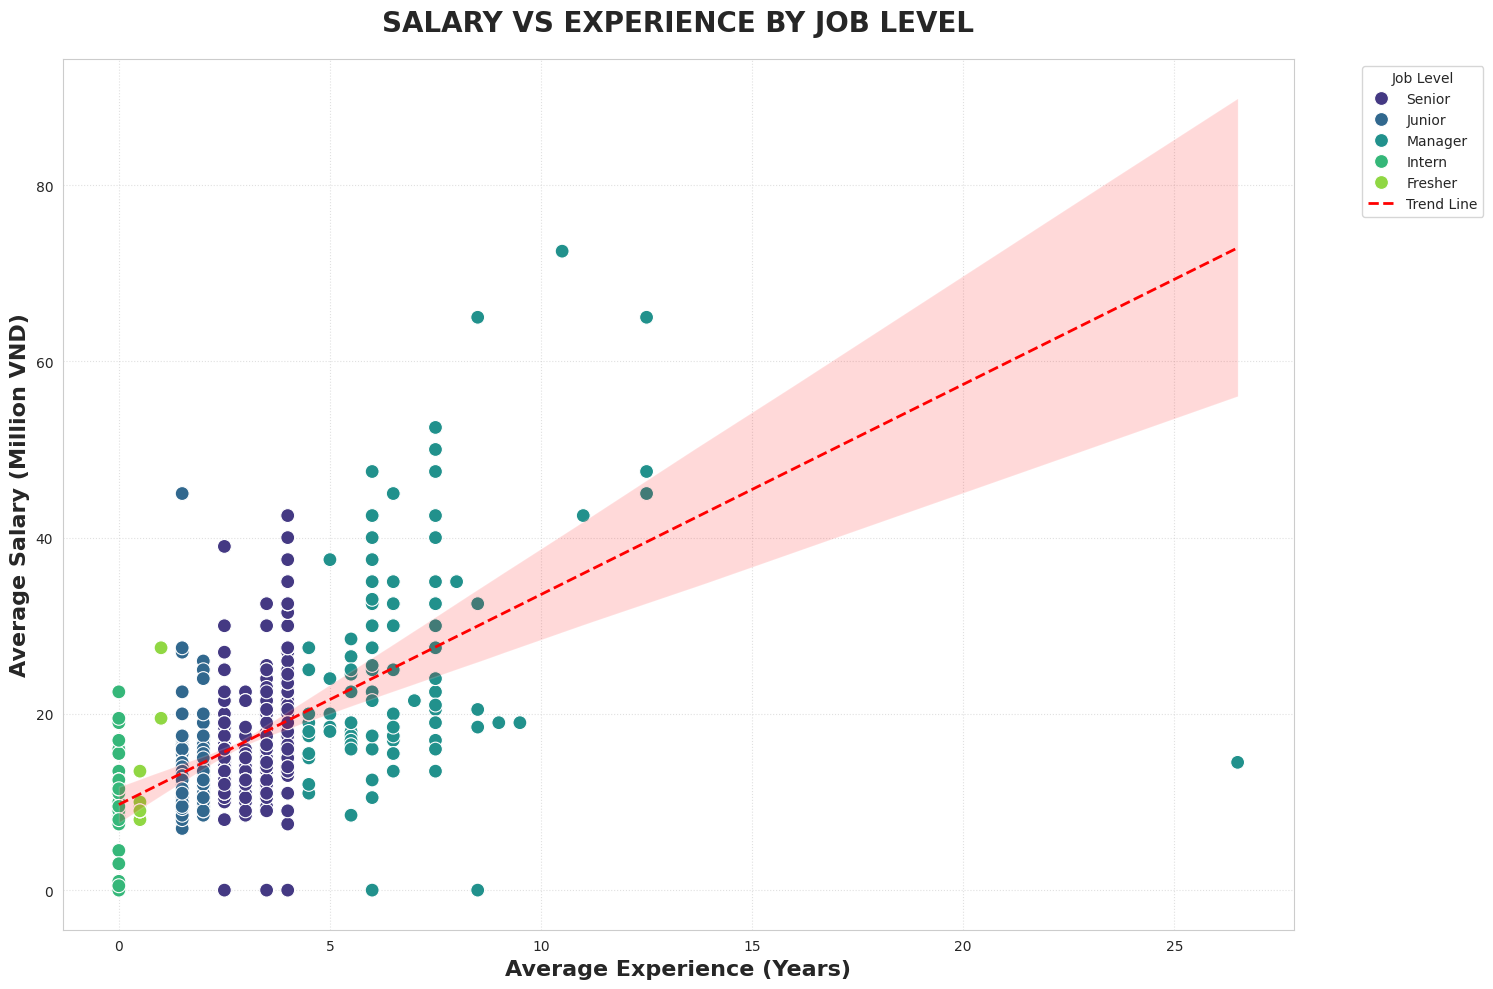

In [ ]:
#Figure 4.1. Distribution of Salary and Experience by Job Level
plt.figure(figsize=(15, 10))
sns.set_style("whitegrid")

ax = sns.scatterplot(data=df, x='experience_avg', y=df['salary_avg']/1e6,
                     hue='job_level', palette='viridis', s=100,
                     alpha=1, edgecolor='w')

sns.regplot(data=df, x='experience_avg', y=df['salary_avg']/1e6,
            scatter=False, color='red',
            line_kws={"ls":"--", "lw":2}, label='Trend Line')

plt.title('SALARY VS EXPERIENCE BY JOB LEVEL', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Average Experience (Years)', fontsize=16, fontweight='bold')
plt.ylabel('Average Salary (Million VND)', fontsize=16, fontweight='bold')
plt.legend(title='Job Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2330/2034425978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=salary_mean.index,


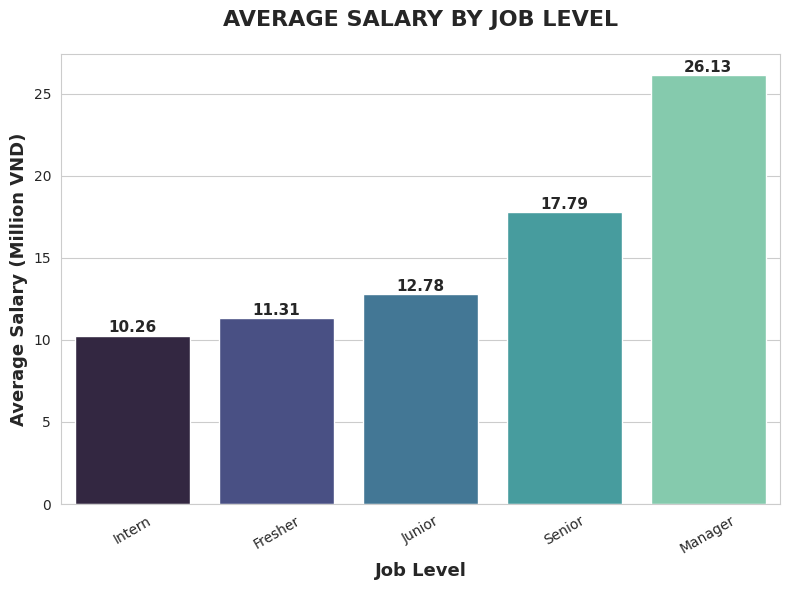

In [ ]:
#Figure 4.2. Distribution of Average Salary by Job Level
plt.figure(figsize=(8, 6))

salary_mean = df.groupby('job_level')['salary_avg'].mean().sort_values()

ax = sns.barplot(x=salary_mean.index,
                 y=salary_mean.values / 1e6,
                 palette='mako')

for i, v in enumerate(salary_mean.values / 1e6):
    ax.text(i, v + 0.2, f"{v:.2f}", ha='center', fontsize=11, fontweight='bold')

plt.title('AVERAGE SALARY BY JOB LEVEL', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Job Level', fontsize=13, fontweight='bold')
plt.ylabel('Average Salary (Million VND)', fontsize=13, fontweight='bold')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

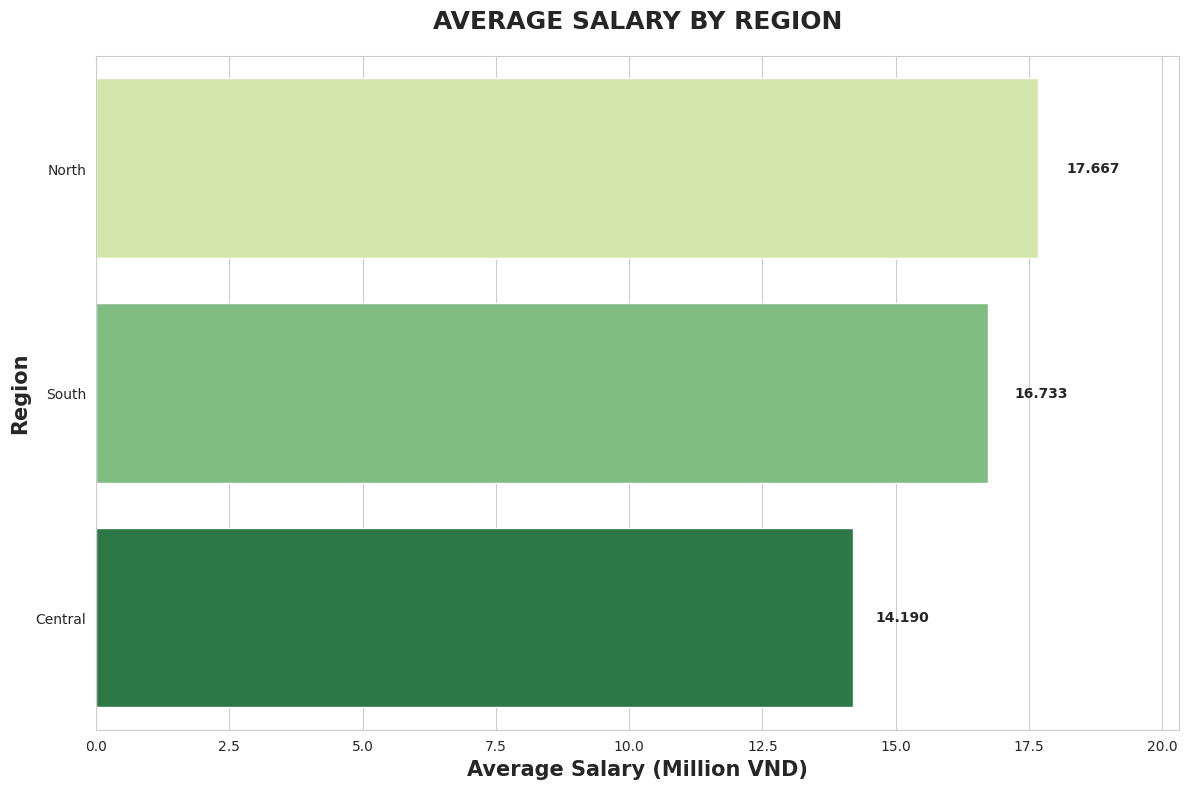

In [ ]:
#Figure 4.3. Distribution of Average Salary by Region
plt.figure(figsize=(12, 8))
region_salary = (df.groupby('region')['salary_avg'].mean()/1e6).sort_values(ascending=False)
ax = sns.barplot(x=region_salary.values, y=region_salary.index,
                 palette='YlGn', hue=region_salary.index, legend=False)

for i, v in enumerate(region_salary.values):
    ax.text(v + (v * 0.03), i, f'{v:,.3f}', va='center', fontweight='bold')

plt.title('AVERAGE SALARY BY REGION', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Average Salary (Million VND)', fontsize=15, fontweight='bold')
plt.ylabel('Region', fontsize=15, fontweight='bold')
plt.xlim(0, region_salary.max() * 1.15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2330/1205942691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=salary_skill.index,


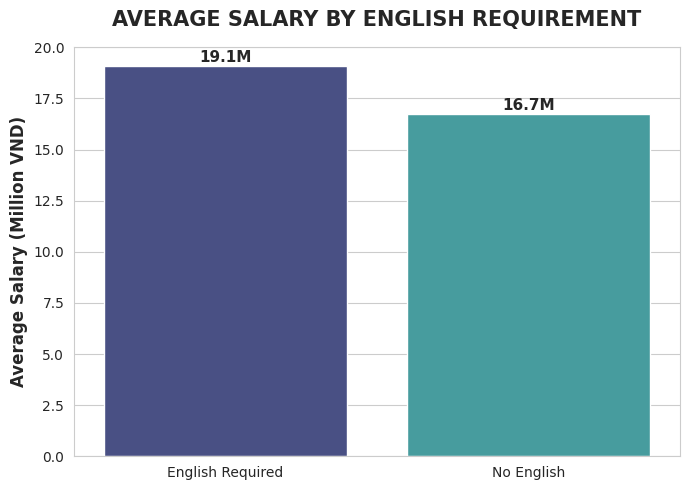

In [ ]:
#Figure 4.4. Impact of English Requirement on Average Salary
plt.figure(figsize=(7, 5))
df['english_label'] = df['english'].map({0: 'No English', 1: 'English Required'})
salary_skill = df.groupby('english_label')['salary_avg'].mean() / 1e6

ax = sns.barplot(x=salary_skill.index,
                 y=salary_skill.values,
                 palette='mako')

for i, v in enumerate(salary_skill.values):
    ax.text(i, v + 0.2, f"{v:.1f}M",
            ha='center', fontsize=11, fontweight='bold')

plt.title('AVERAGE SALARY BY ENGLISH REQUIREMENT',
          fontsize=15, fontweight='bold', pad=15)

plt.xlabel('')
plt.ylabel('Average Salary (Million VND)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

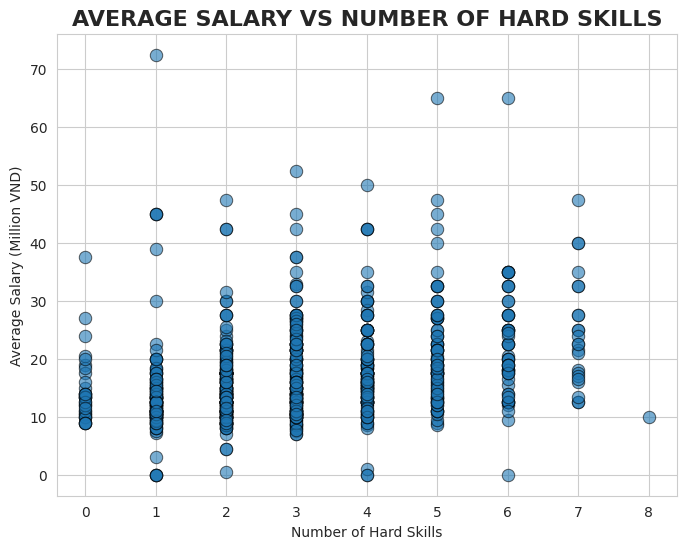

In [ ]:
#Figure 4.5. Impact of Hard Skills on Salary
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="num_hard",
    y=df["salary_avg"]/1e6,
    s=80,
    alpha=0.6,
    edgecolor='black'
)
plt.title("Average Salary vs Number of Hard Skills".upper(), fontsize=16, fontweight="bold")
plt.xlabel("Number of Hard Skills")
plt.ylabel("Average Salary (Million VND)")
plt.show()

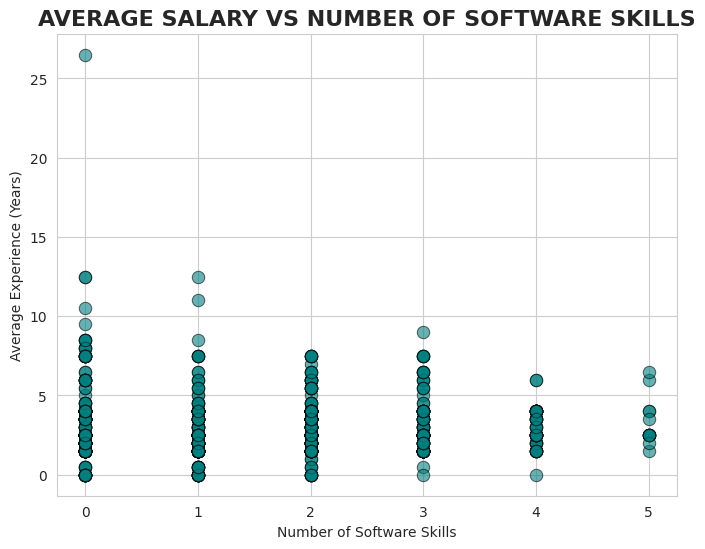

In [ ]:
#Figure 4.6. Impact of Software Skills on Salary
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="num_software",
    y="experience_avg",
    s=80,
    alpha=0.6,
    edgecolor='black',
    color='teal'
)
plt.title("Average Salary vs Number of Software Skills".upper(), fontsize=16, fontweight="bold")
plt.xlabel("Number of Software Skills")
plt.ylabel("Average Experience (Years)")
plt.show()

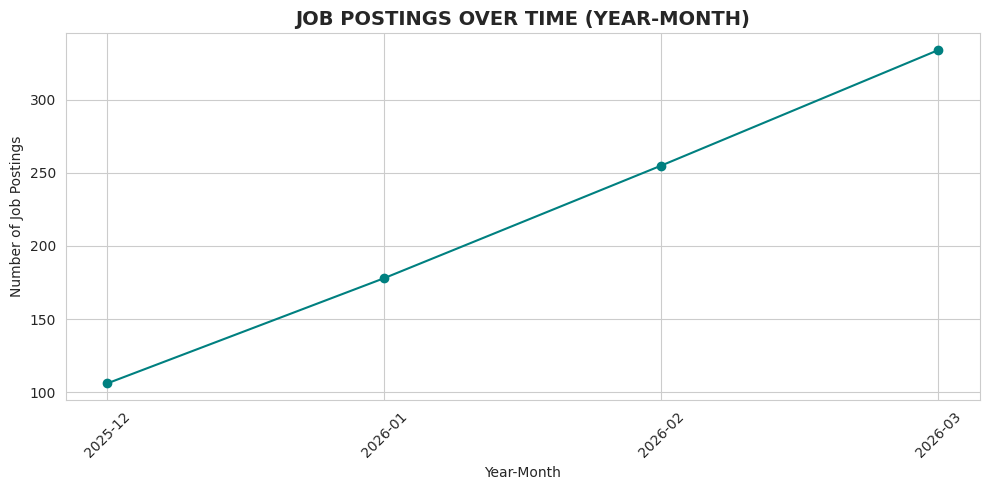

In [ ]:
#Figure 4.7. Trend of Job Postings Over Time
df['year_month'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)
job_trend = df.groupby('year_month').size()

plt.figure(figsize=(10, 5))

plt.plot(job_trend.index, job_trend.values, marker="o", color='teal')

plt.title("JOB POSTINGS OVER TIME (YEAR-MONTH)", fontsize=14, fontweight="bold")
plt.xlabel("Year-Month")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

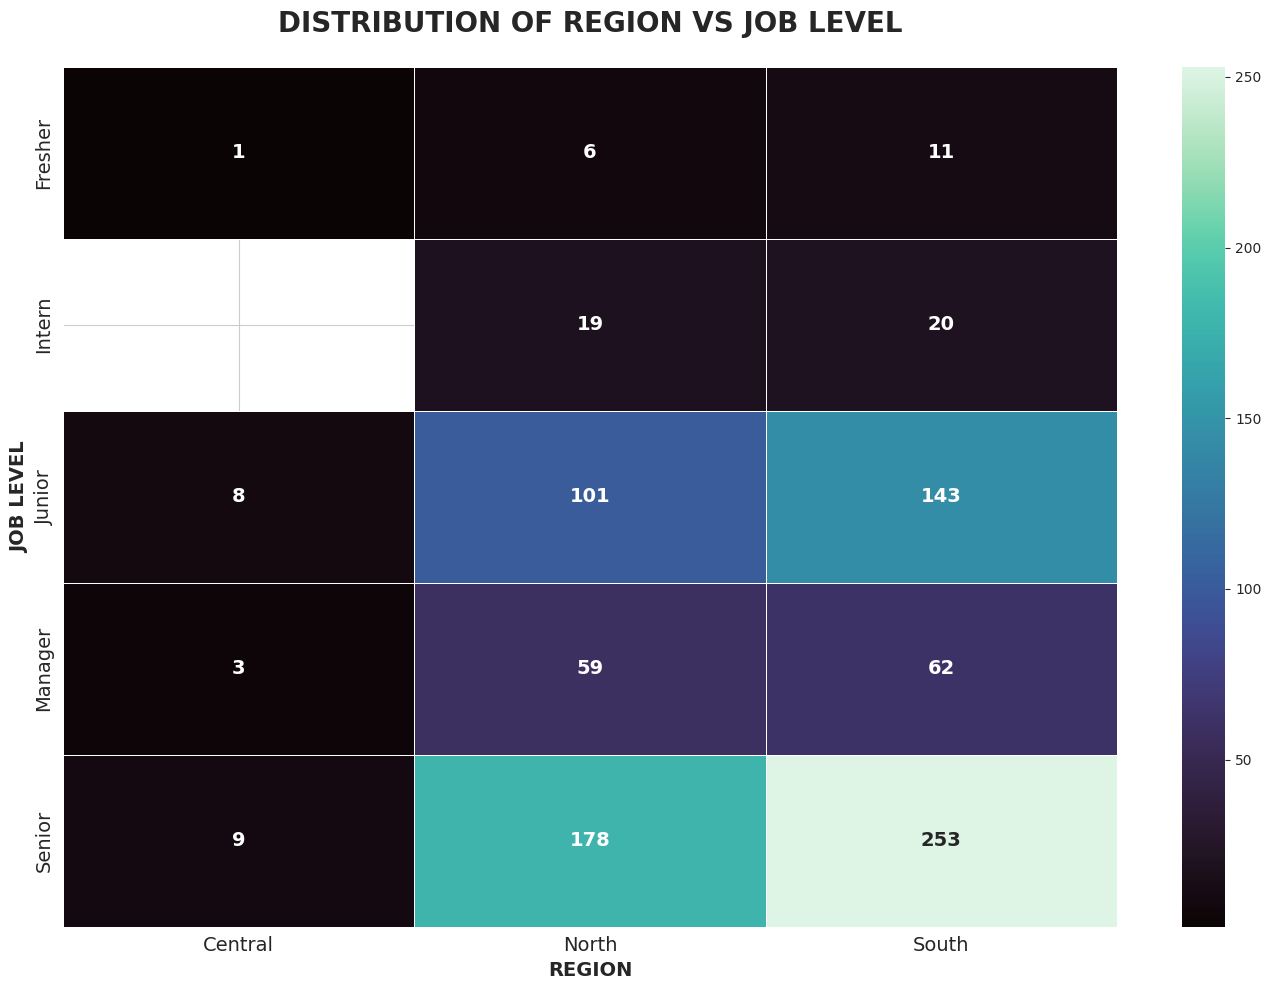

In [ ]:
#Figure 4.8. Distribution of Region and Job Level
pivot_table = df.pivot_table(index='job_level',
                             columns='region',
                             aggfunc='size')

plt.figure(figsize=(14, 10))
ax = sns.heatmap(pivot_table, annot=True, fmt='g', cmap='mako',
                 linewidths=0.5, annot_kws={"size": 14, "weight": "bold"})

plt.title('DISTRIBUTION OF REGION VS JOB LEVEL', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('REGION', fontsize=14, fontweight='bold')
plt.ylabel('JOB LEVEL', fontsize=14, fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
hard_skills = ['accounting', 'reporting', 'finance', 'management', 'monitoring',
               'inspection', 'english', 'accounts payable', 'reconciliation', 'audit',
               'inventory checking', 'tax finalization', 'cash inflow/outflow', 'analysis']

software_skills = ['accounting software', 'excel', 'misa', 'fast', 'sap', 'erp']

soft_skills = ['communication', 'teamwork', 'honesty', 'careful', 'responsibility',
               'proactiveness', 'work under pressure', 'detail oriented']

all_skills = hard_skills + software_skills + soft_skills

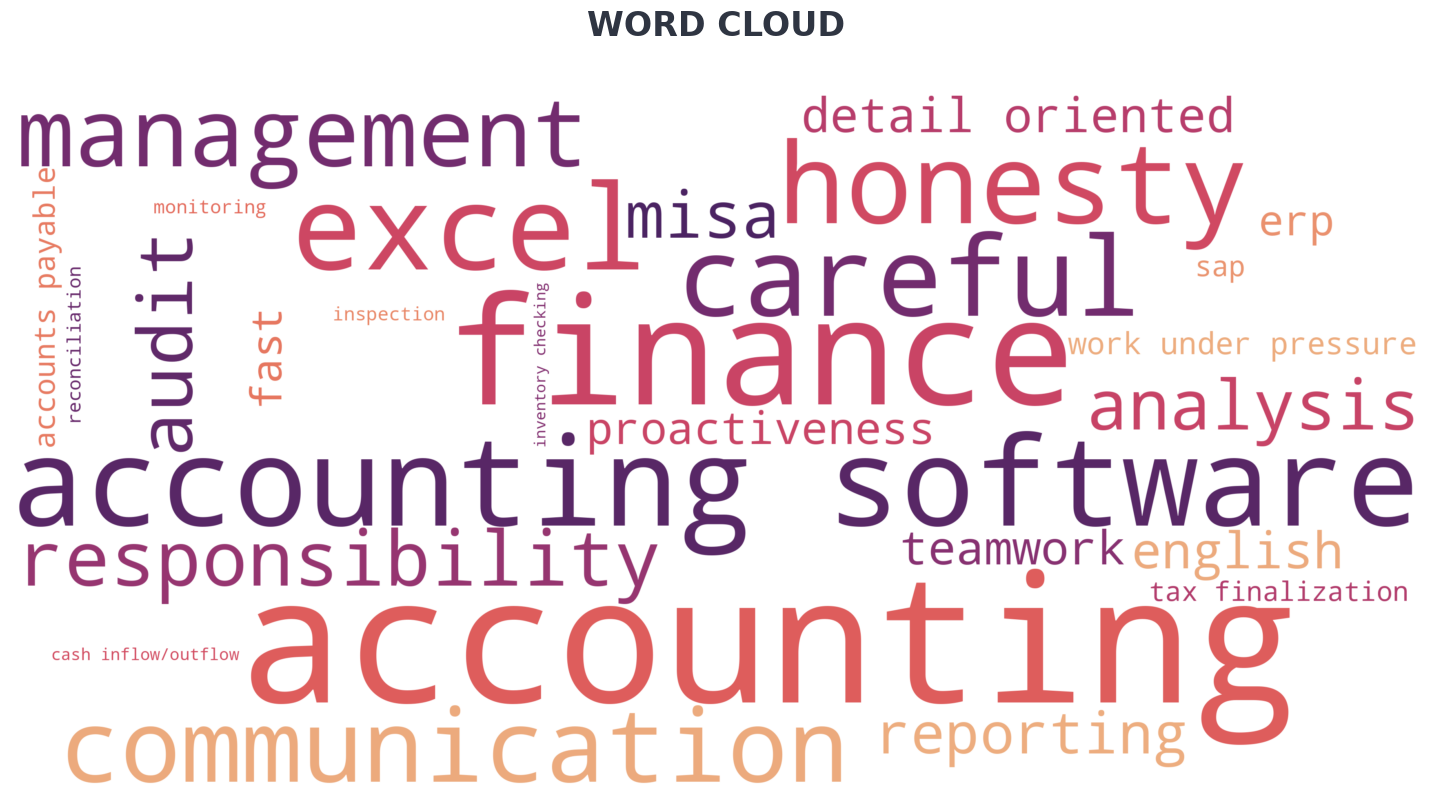

In [ ]:
#Figure 4.9. Word Cloud Visualization
skill_counts = df[all_skills].sum().sort_values(ascending=False)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='flare',
    max_words=100,
    min_font_size=10,
    max_font_size=150,
    prefer_horizontal=0.85,
    relative_scaling=0.5,
    scale=3
).generate_from_frequencies(skill_counts.to_dict())

plt.figure(figsize=(15, 8), dpi=100)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.title('WORD CLOUD',
          fontsize=24,
          fontweight='bold',
          color='#2f3542',
          pad=40,
          loc='center')

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_color('#eeeeee')

plt.tight_layout()
plt.show()

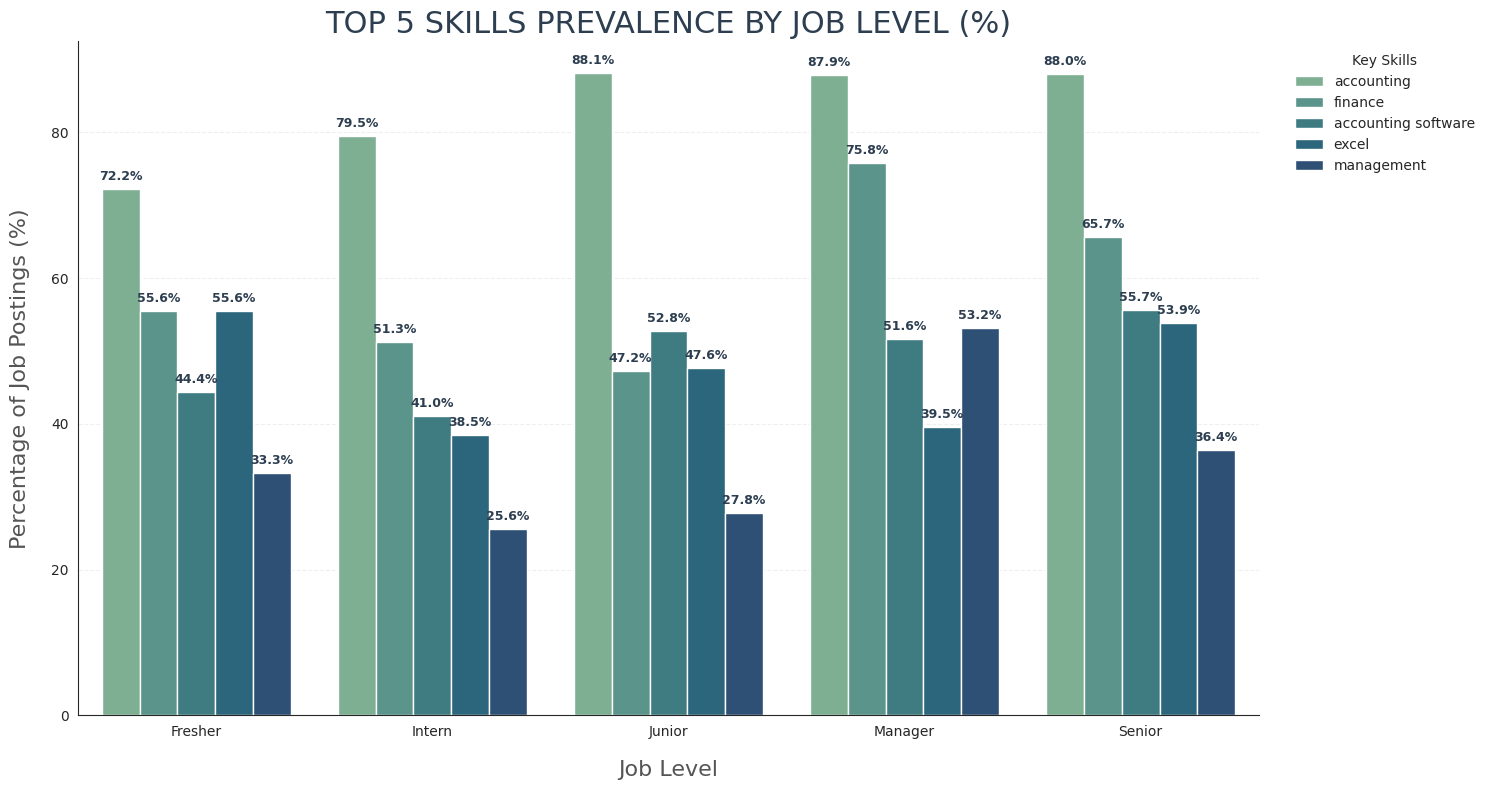

In [ ]:
#Figure 4.10. Top 5 Skills Prevalence by Job Level
tech_skills = hard_skills + software_skills
tech_counts = df[tech_skills].sum().sort_values(ascending=False)

top_5_skills = tech_counts.head(5).index.tolist()
skills_by_level = df.groupby('job_level')[top_5_skills].mean() * 100
df_plot = skills_by_level.reset_index().melt(id_vars='job_level',
                                             var_name='Skill',
                                             value_name='Percentage')

plt.figure(figsize=(15, 8))
sns.set_style("white")

ax = sns.barplot(
    data=df_plot,
    x='job_level',
    y='Percentage',
    hue='Skill',
    palette='crest',
    edgecolor='white',
    linewidth=1
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    fontsize=9, color='#2c3e50',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontweight='bold')

plt.title('TOP 5 SKILLS PREVALENCE BY JOB LEVEL (%)',fontsize=22, color='#2c3e50')
plt.ylabel('Percentage of Job Postings (%)', labelpad=15, fontsize=16, color='#555555')
plt.xlabel('Job Level', labelpad=15, fontsize=16, color='#555555')
plt.xticks(rotation=0)

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.legend(title='Key Skills', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()


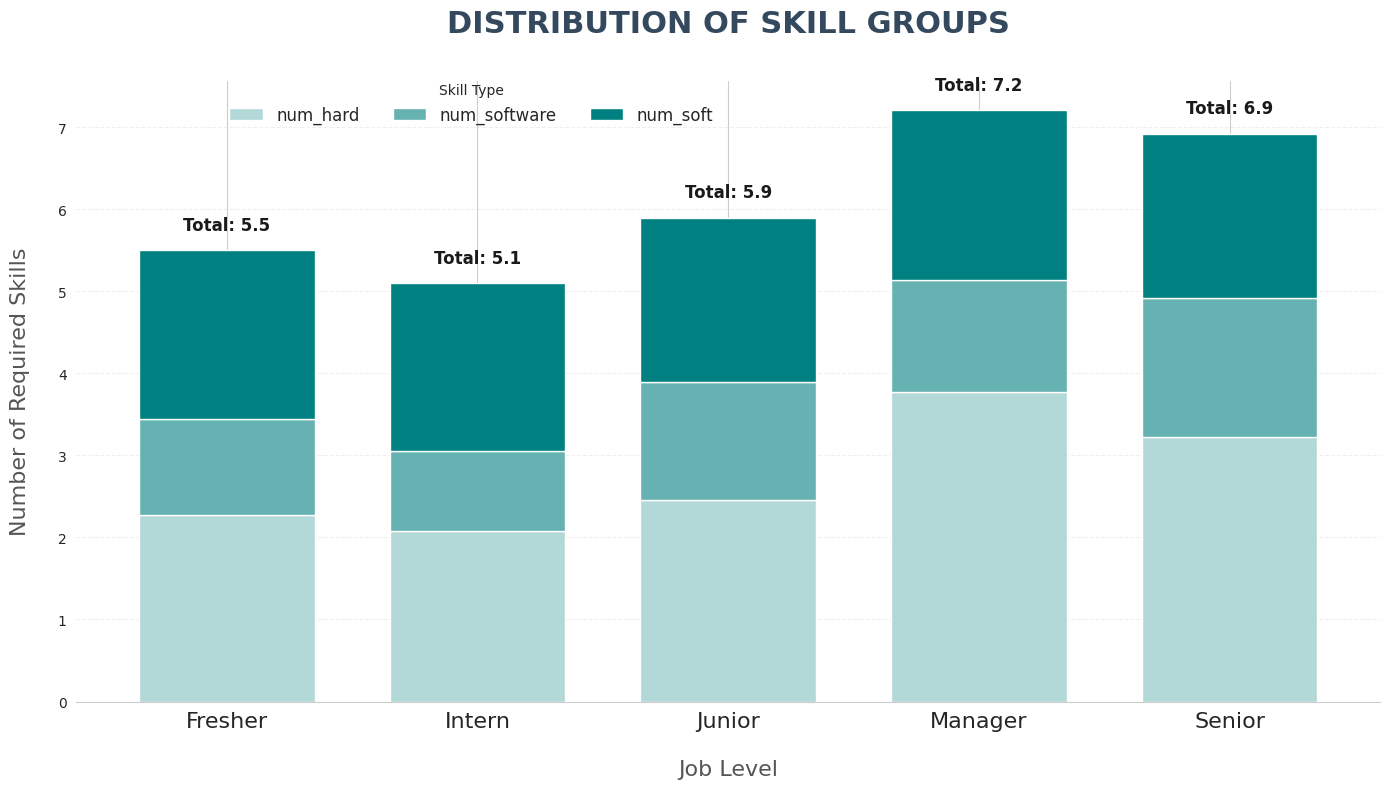

In [ ]:
#Figure 4.11. Distribution of Skill Groups
dist_by_level = df.groupby('job_level')[['num_hard', 'num_software', 'num_soft']].mean()
colors = ['#b2d8d8', '#66b2b2', '#008080']
sns.set_style('whitegrid')
ax = dist_by_level.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    width=0.7,
    color=colors,
    edgecolor='white',
    linewidth=1
)

totals = dist_by_level.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, total + 0.2, f'Total: {total:.1f}',
            ha='center', va='bottom',
            fontsize=12, color='#1a1a1a', fontweight='bold')

plt.title('DISTRIBUTION OF SKILL GROUPS',
          fontsize=22, fontweight='bold', pad=35, color='#34495e')

plt.ylabel('Number of Required Skills', fontsize=16, labelpad=20, color='#555555')
plt.xlabel('Job Level', fontsize=16, labelpad=20, color='#555555')
plt.xticks(rotation=0, fontsize=16)

sns.despine(left=True)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

plt.legend(title='Skill Type',bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

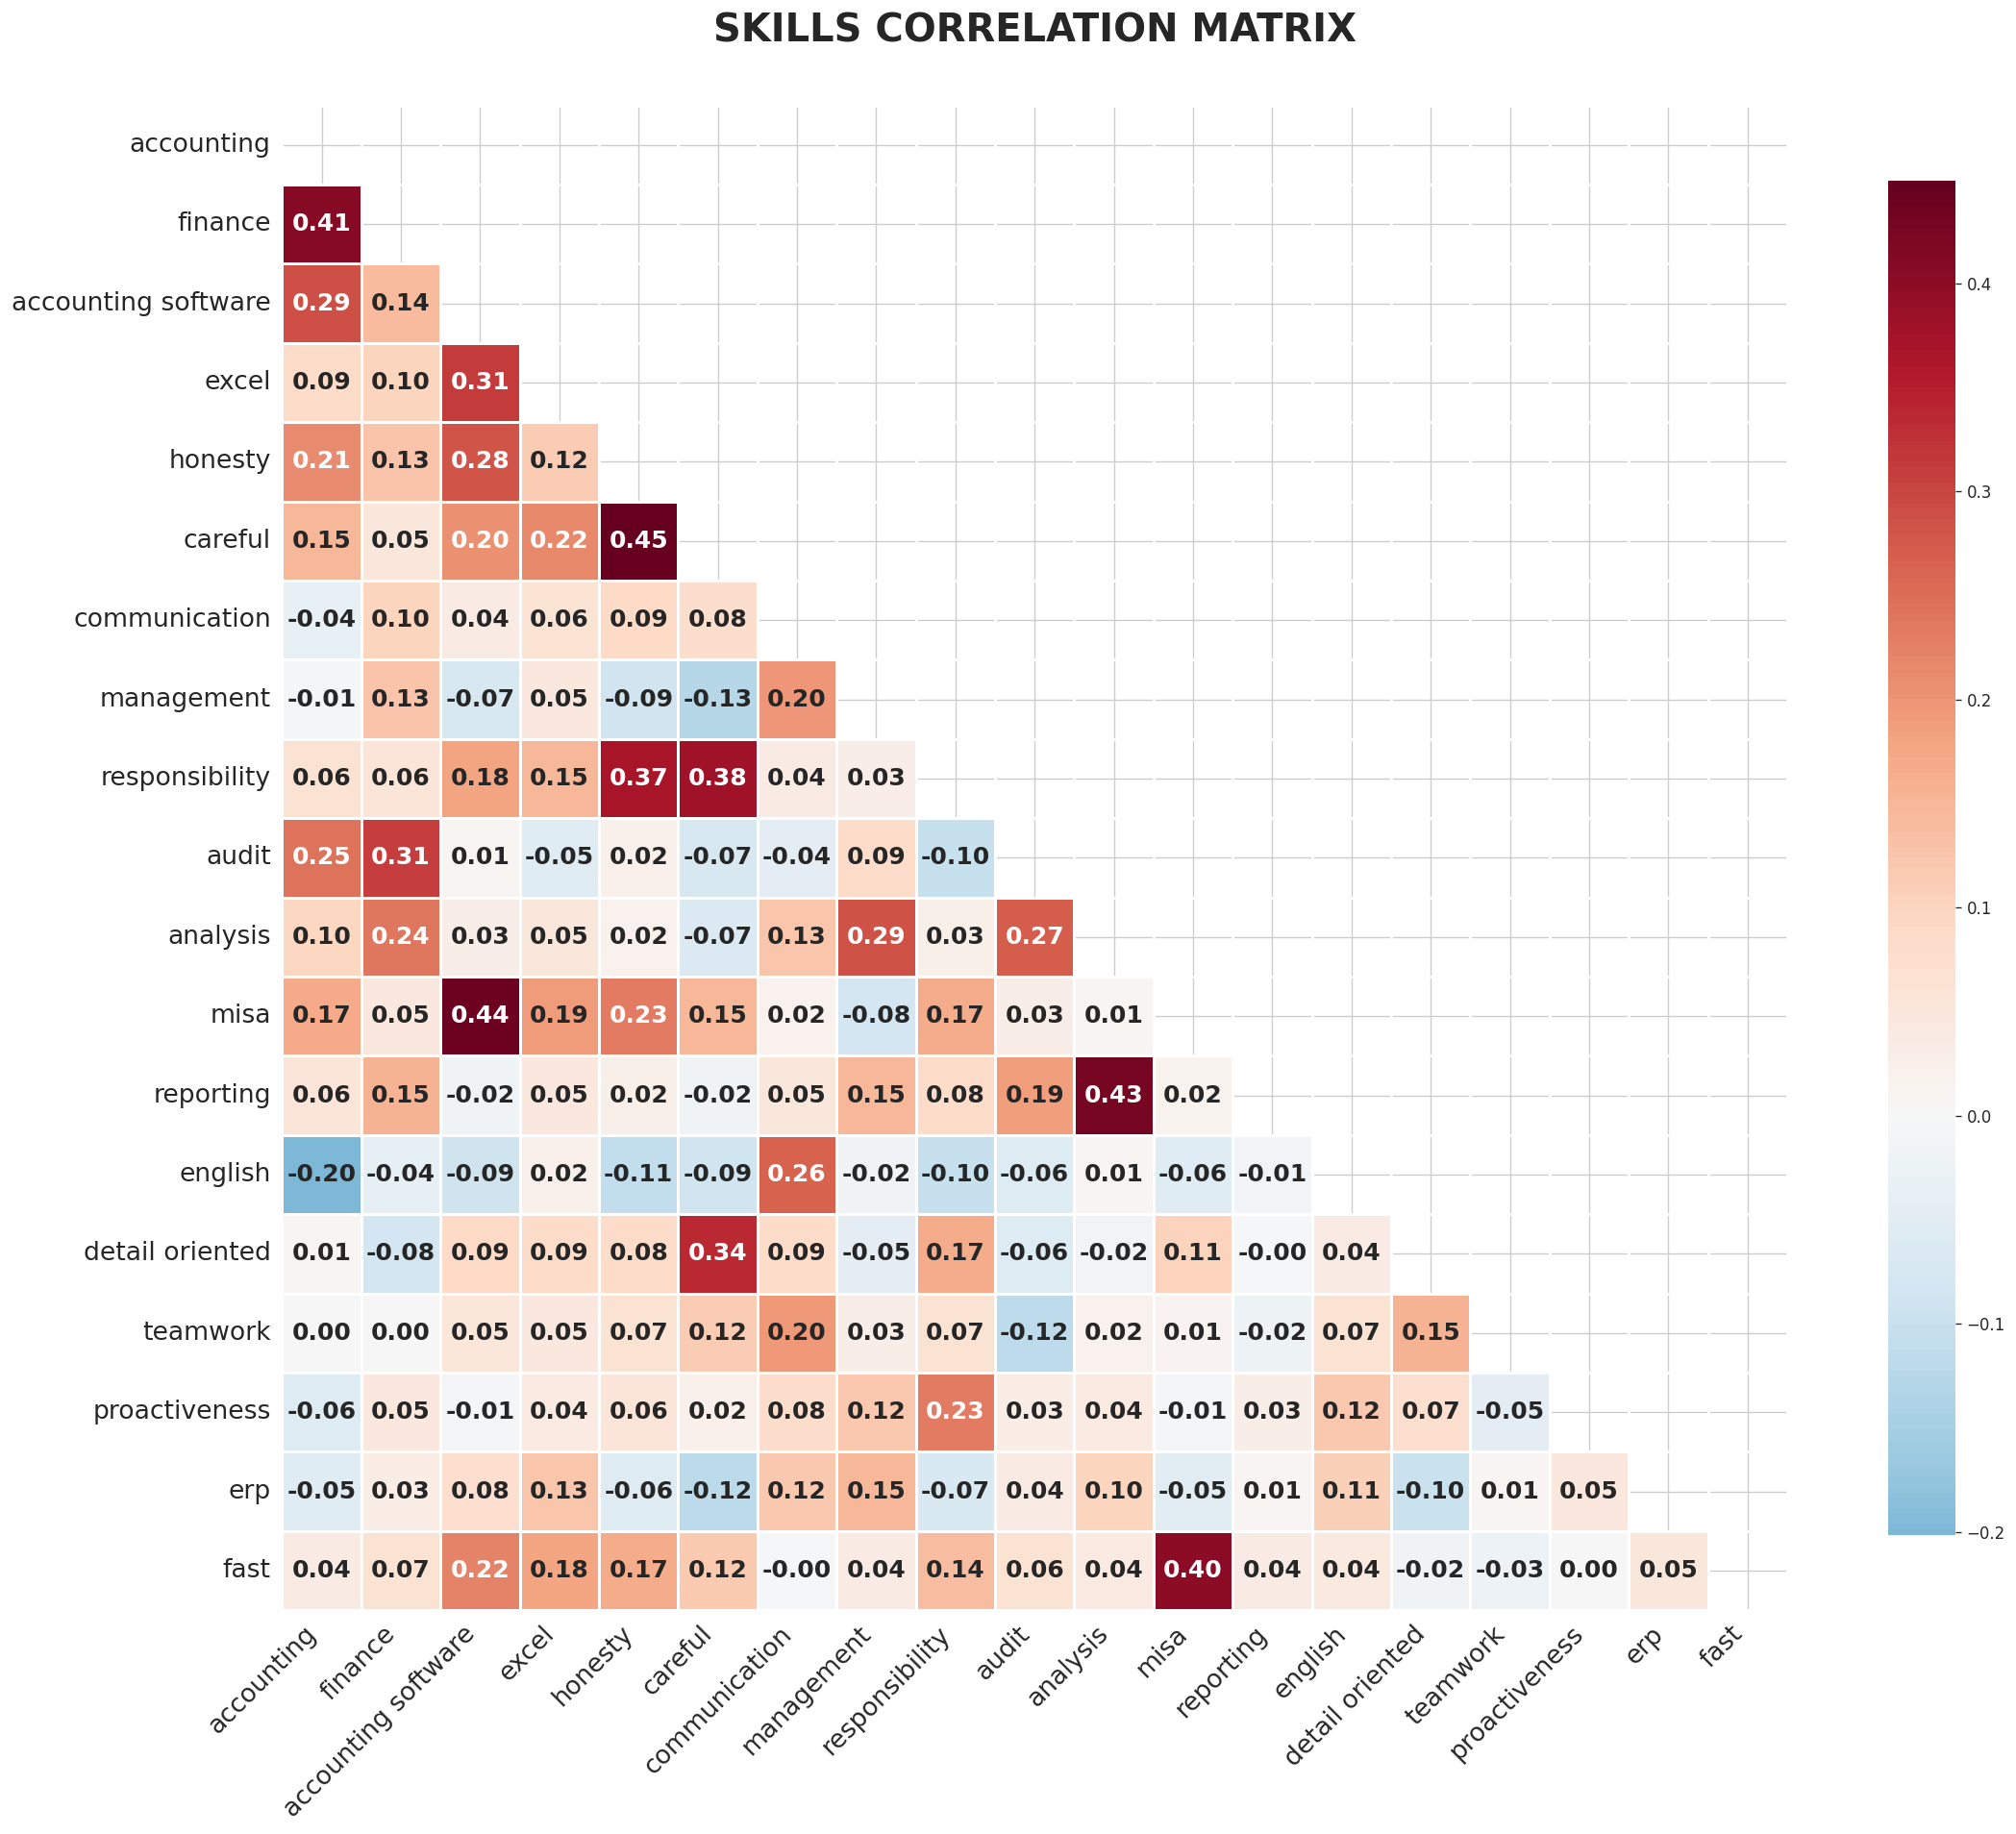

In [ ]:
#Figure 4.12. Skills Correlation Matrix
common_skills = skill_counts[skill_counts > (len(df)*0.1)].index.tolist()
corr = df[common_skills].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(20, 16), dpi=120)

ax = sns.heatmap(
    corr,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 15, "weight": "bold"},
    linewidths=1.5,
    cbar_kws={"shrink": 0.9},
    square=True
)

plt.title('SKILLS CORRELATION MATRIX',
          fontsize=24, pad=40, fontweight='bold')
plt.xticks(fontsize=16, rotation=45, ha='right')
plt.yticks(fontsize=16)

plt.tight_layout()
plt.show()

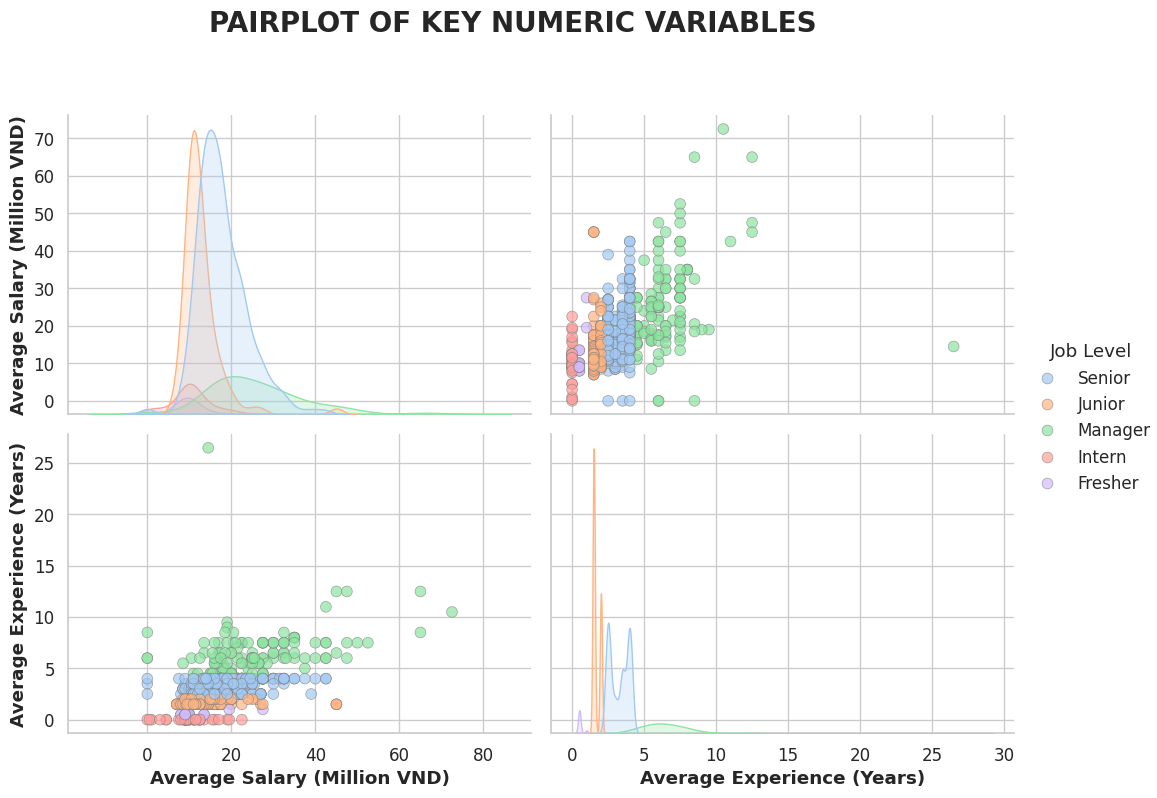

In [ ]:
#Figure 4.13. Pairplot of Key Numeric Variables
subset_df = df.assign(salary_m = df['salary_avg'] / 1e6)[
    ['salary_m', 'experience_avg', 'job_level']
]
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

g = sns.pairplot(
    subset_df,
    hue='job_level',
    palette='pastel',
    diag_kind='kde',
    height=3.8,
    aspect=1.2,
    plot_kws={
        'alpha': 0.7,
        's': 60,
        'edgecolor': 'gray',
        'linewidth': 0.5
    },
    diag_kws={'fill': True}
)
replacements = {
    'salary_m': 'Average Salary (Million VND)',
    'experience_avg': 'Average Experience (Years)',
    'job_level': 'Job Level'
}

for i in range(len(g.axes)):
    for j in range(len(g.axes[i])):
        xlabel = g.axes[i][j].get_xlabel()
        if xlabel in replacements:
            g.axes[i][j].set_xlabel(replacements[xlabel], fontweight='bold')
        ylabel = g.axes[i][j].get_ylabel()
        if ylabel in replacements:
            g.axes[i][j].set_ylabel(replacements[ylabel], fontweight='bold')

g.fig.suptitle('Pairplot of Key Numeric Variables'.upper(), fontsize=20, fontweight='bold', y=1.05)
g._legend.set_title('Job Level')
g._legend.set_bbox_to_anchor((1.115, 0.5))
g._legend.get_frame().set_edgecolor('gray')
g._legend.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2330/2928460769.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


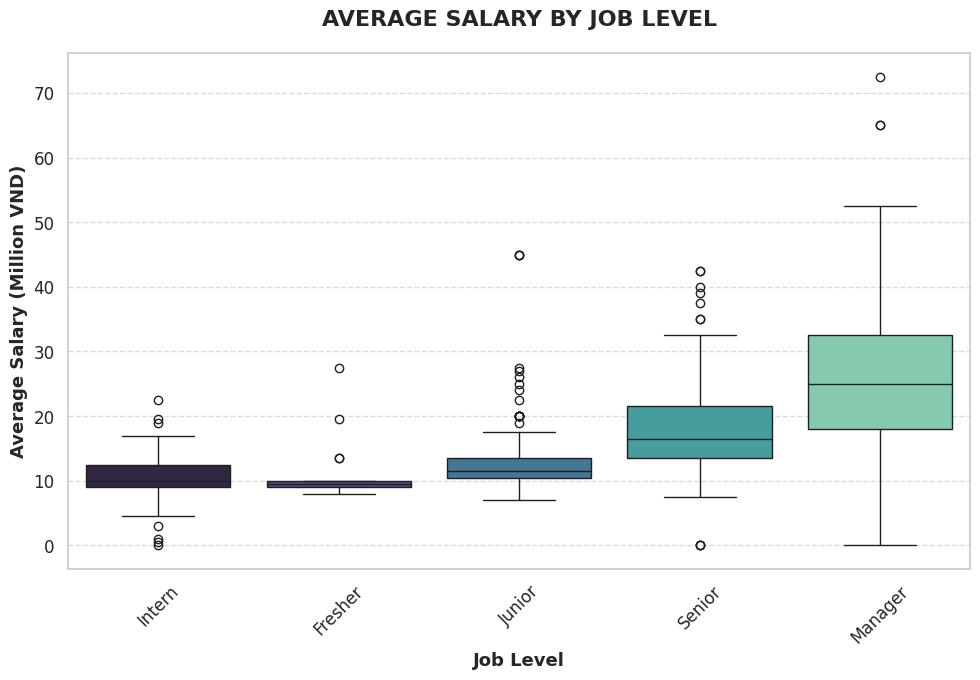

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

ax = sns.boxplot(
    x='job_level',
    y=df['salary_avg'] / 1e6,
    data=df,
    palette='mako',
    order=['Intern', 'Fresher', 'Junior', 'Senior', 'Manager'] )

job_level_order = [tick.get_text() for tick in ax.get_xticklabels()]
average_salaries = df.groupby('job_level')['salary_avg'].mean().loc[job_level_order].values / 1e6

plt.title('AVERAGE SALARY BY JOB LEVEL', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Job Level', fontsize=13, fontweight='bold')
plt.ylabel('Average Salary (Million VND)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#Đếm số job có English
english_jobs = (df["english"] == 1).sum()
print("Số job cần English:", english_jobs)
no_english_jobs = (df["english"] == 0).sum()
print("Số job không cần English:", no_english_jobs)
total_jobs = len(df)
print("Tổng số job:", total_jobs)
english_pct = english_jobs / total_jobs * 100
no_english_pct = no_english_jobs / total_jobs * 100
print(f"Tỷ lệ job cần English: {english_pct:.2f}%")
print(f"Tỷ lệ job không cần English: {no_english_pct:.2f}%")

Số job cần English: 128
Số job không cần English: 745
Tổng số job: 873
Tỷ lệ job cần English: 14.66%
Tỷ lệ job không cần English: 85.34%


Số job cần English: 128
Số job không cần English: 745
Tổng số job: 873
Tỷ lệ job cần English: 14.66%
Tỷ lệ job không cần English: 85.34%


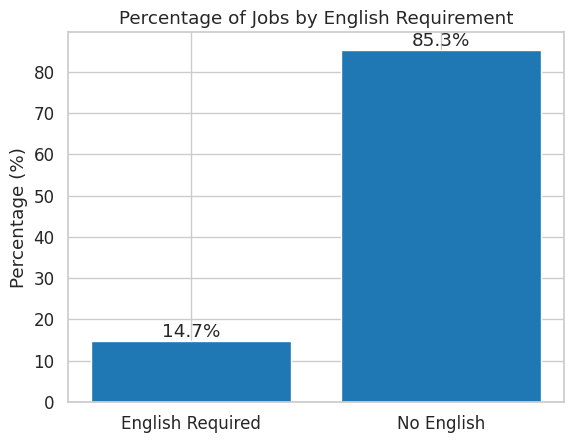

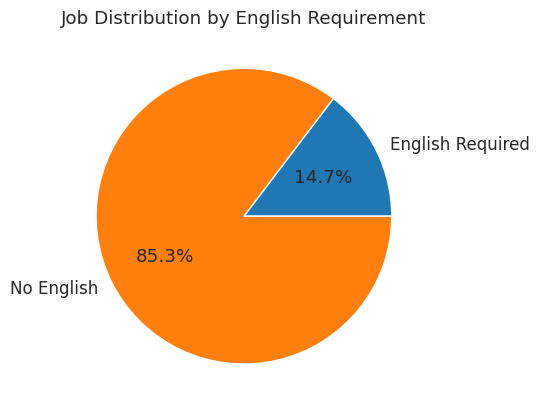

In [ ]:
import matplotlib.pyplot as plt

# --- PHẦN BẠN ĐÃ CÓ ---
english_jobs = (df["english"] == 1).sum()
print("Số job cần English:", english_jobs)

no_english_jobs = (df["english"] == 0).sum()
print("Số job không cần English:", no_english_jobs)

total_jobs = len(df)
print("Tổng số job:", total_jobs)

english_pct = english_jobs / total_jobs * 100
no_english_pct = no_english_jobs / total_jobs * 100

print(f"Tỷ lệ job cần English: {english_pct:.2f}%")
print(f"Tỷ lệ job không cần English: {no_english_pct:.2f}%")


# --- VẼ BIỂU ĐỒ CỘT ---
labels = ["English Required", "No English"]
percentages = [english_pct, no_english_pct]

plt.figure()
plt.bar(labels, percentages)
plt.ylabel("Percentage (%)")
plt.title("Percentage of Jobs by English Requirement")

# hiển thị % trên cột
for i, v in enumerate(percentages):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.show()


# --- VẼ BIỂU ĐỒ TRÒN ---
plt.figure()
plt.pie(percentages, labels=labels, autopct='%1.1f%%')
plt.title("Job Distribution by English Requirement")
plt.show()

=== SUMMARY ===
English Required: 14.66% | Avg Salary: 19068417.19
No English: 85.34% | Avg Salary: 16715371.01


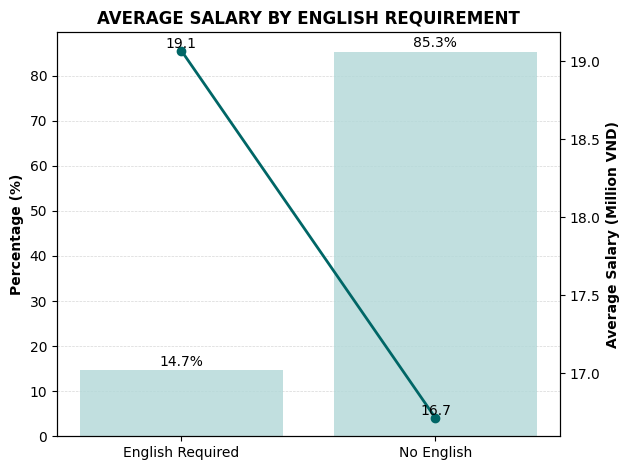

In [ ]:
# Số lượng job
english_jobs = (df["english"] == 1).sum()
no_english_jobs = (df["english"] == 0).sum()
total_jobs = len(df)

# Tỷ lệ %
english_pct = english_jobs / total_jobs * 100
no_english_pct = no_english_jobs / total_jobs * 100

# Lương trung bình (DÙNG salary_avg)
avg_salary_english = df[df["english"] == 1]["salary_avg"].mean()
avg_salary_no_english = df[df["english"] == 0]["salary_avg"].mean()

print("=== SUMMARY ===")
print(f"English Required: {english_pct:.2f}% | Avg Salary: {avg_salary_english:.2f}")
print(f"No English: {no_english_pct:.2f}% | Avg Salary: {avg_salary_no_english:.2f}")
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

labels = ["English Required", "No English"]

# dữ liệu
percentages = [english_pct, no_english_pct]
avg_salaries_mil = [
    avg_salary_english / 1e6,
    avg_salary_no_english / 1e6
]

# style sạch
plt.style.use('default')

fig, ax1 = plt.subplots()

# --- BAR: % ---
bars = ax1.bar(labels, percentages, alpha=0.8, color='#b2d8d8')
ax1.set_ylabel("Percentage (%)", fontweight='bold')

# bỏ grid hoặc cho xuống dưới
ax1.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
ax1.set_axisbelow(True)  # grid nằm dưới cột

# hiển thị %
for i, v in enumerate(percentages):
    ax1.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10)

# --- LINE: salary ---
ax2 = ax1.twinx()
ax2.plot(labels, avg_salaries_mil, marker='o', linewidth=2, color='#006666')

ax2.set_ylabel("Average Salary (Million VND)", fontweight='bold')

# hiển thị lương
for i, v in enumerate(avg_salaries_mil):
    ax2.text(i, v, f"{v:.1f}", ha='center', va='bottom', fontsize=10)

# title
plt.title("AVERAGE SALARY BY ENGLISH REQUIREMENT", fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df_kmeans = df.copy()

features = ['salary_avg', 'experience_avg']
X = df_kmeans[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

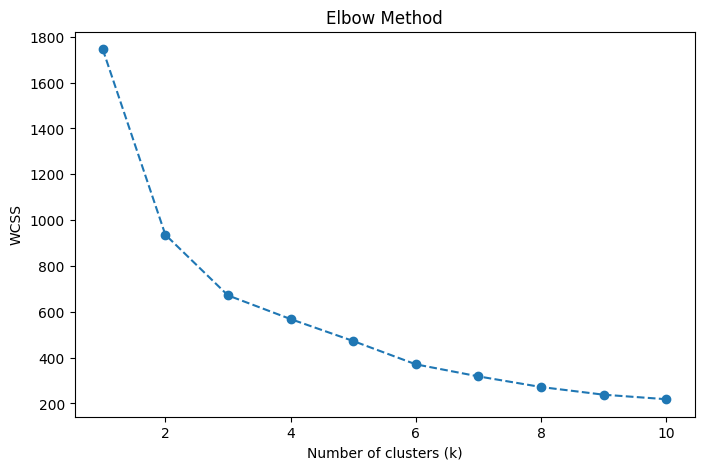

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans.fit_transform(X_scaled)
df_kmeans['Cluster'] = kmeans.labels_

Text(0, 0.5, 'Average salary (Million VND)')

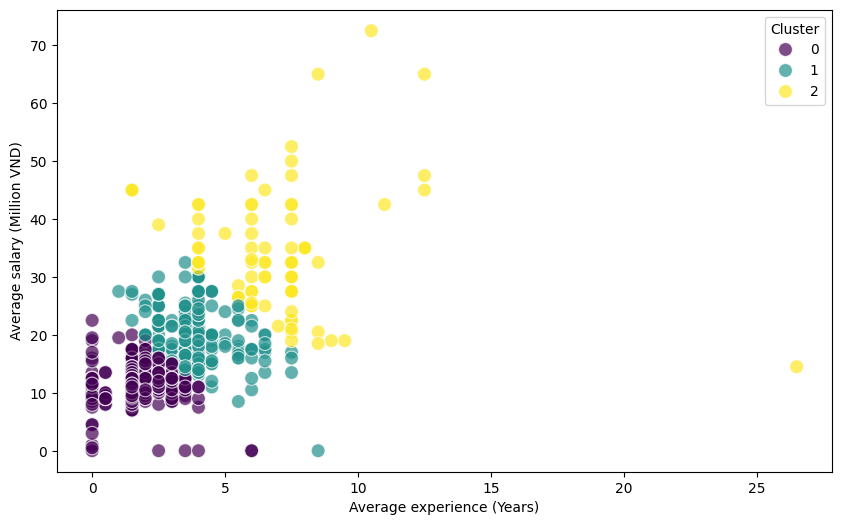

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_kmeans['experience_avg'],
    y=df_kmeans['salary_avg']/1e6,
    hue=df_kmeans['Cluster'],
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.xlabel('Average experience (Years)')
plt.ylabel('Average salary (Million VND)')

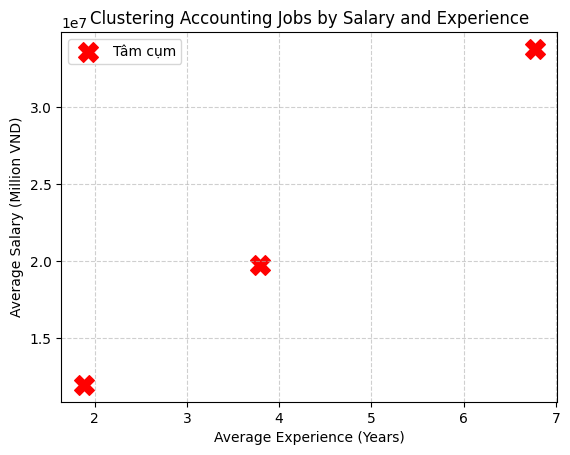

In [ ]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 1], centroids[:, 0], c='red', s=200, marker='X', label='Tâm cụm')

plt.title('Clustering Accounting Jobs by Salary and Experience')
plt.xlabel('Average Experience (Years)')
plt.ylabel('Average Salary (Million VND)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
cluster_summary = df_kmeans.groupby('Cluster')[['salary_avg', 'experience_avg']].agg(['mean', 'min', 'max', 'count'])
print("Detailed statistics for each cluster:")
print(cluster_summary)

Detailed statistics for each cluster:
           salary_avg                               experience_avg             \
                 mean         min         max count           mean  min   max   
Cluster                                                                         
0        1.198088e+07       450.0  22500000.0   460       1.883696  0.0   6.0   
1        1.976688e+07      2400.0  32500000.0   326       3.792945  1.0   8.5   
2        3.377586e+07  14500000.0  72500000.0    87       6.770115  1.5  26.5   

               
        count  
Cluster        
0         460  
1         326  
2          87  


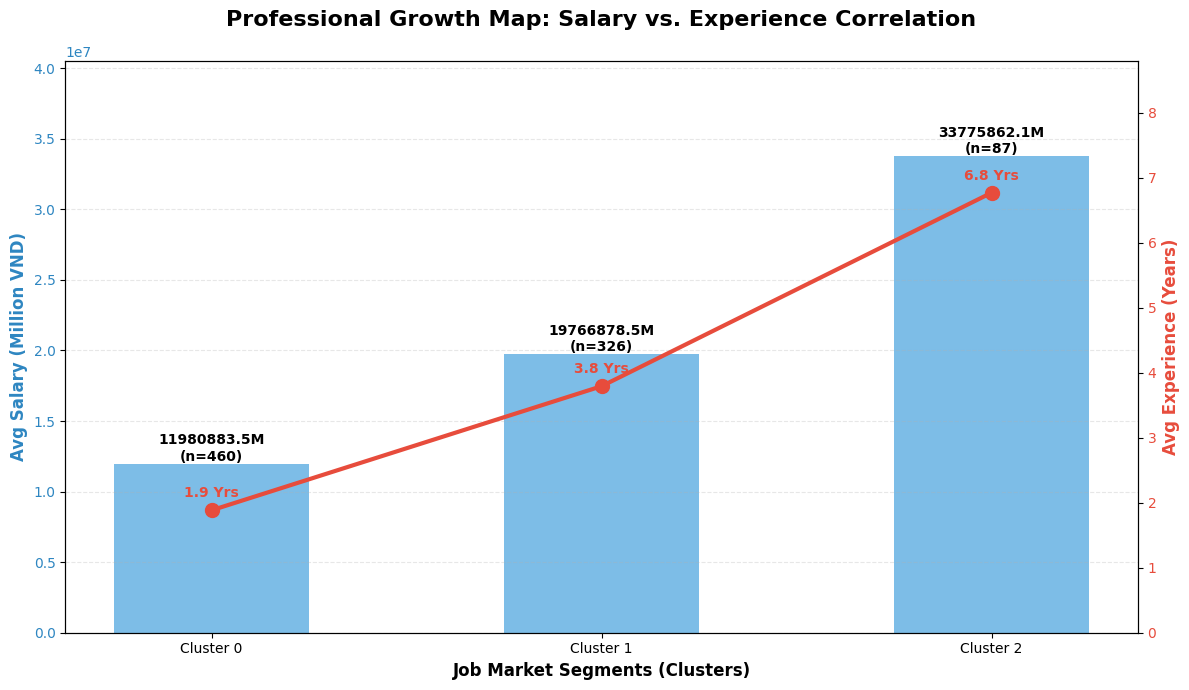

In [ ]:
clusters = [f'Cluster {i}' for i in cluster_summary.index]
salary_means = cluster_summary['salary_avg']['mean'].values
exp_means = cluster_summary['experience_avg']['mean'].values
counts = cluster_summary['salary_avg']['count'].values

fig, ax1 = plt.subplots(figsize=(12, 7))

color_salary = '#5dade2'
ax1.set_xlabel('Job Market Segments (Clusters)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Avg Salary (Million VND)', color='#2e86c1', fontsize=12, fontweight='bold')
bars = ax1.bar(clusters, salary_means, color=color_salary, alpha=0.8, width=0.5, label='Avg Salary')
ax1.tick_params(axis='y', labelcolor='#2e86c1')

ax1.set_ylim(0, max(salary_means) * 1.2)

ax2 = ax1.twinx()
color_exp = '#e74c3c'
ax2.set_ylabel('Avg Experience (Years)', color=color_exp, fontsize=12, fontweight='bold')
line = ax2.plot(clusters, exp_means, color=color_exp, marker='o', markersize=10, linewidth=3, label='Avg Experience')
ax2.tick_params(axis='y', labelcolor=color_exp)

ax2.set_ylim(0, max(exp_means) * 1.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}M\n(n={counts[i]:.0f})',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

for i, v in enumerate(exp_means):
    ax2.text(i, v + 0.2, f'{v:.1f} Yrs', color=color_exp, ha='center', fontweight='bold')

plt.title('Professional Growth Map: Salary vs. Experience Correlation', fontsize=16, pad=25, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()